## LR
---------------------------------------------------
### DELTA valamivel jobb eredményekre vezetett
---------------------------------------------------
#### Pipeline:
- kétféle adat:
	- delta: csak a delta változók vannak benne, mert ezek az alapadatokból (kör- és szektoridők, gumik kora, stb.) lettek számolva, így teljes korreláltság volt változók közzött --> VIF elszált a végtelenbe
	- wocorner: mivel a sectorok leírásában a corner/corners szavak rendkívül gyakoriak voltak, ezeket kivettem, hátha a TF-IDF, és ezen keresztül a modell is jobb eredményre vezet (úgy néz ki, hogy nem, sőt, az XGBoostban több megoldást is kipróbáltam erre [LR+TF-IDF, TF-IDF+naive bayes, target encoding], és mindhárom 59+-1%-os teljesítményt ért el a Sikeres predikálásában, azaz gyakorlatilag felesleges volt a sok cirkusz ezért :) )
- multikollinearitás kiszámolása és korrelációs mátrix ábrázolása + elmentése
- VIF:
	- előbb kiszámolom
	- majd minden iterációban kidobom a legmagasabb VIF-fel rendelkező változót egészen addig, amíg minden változó VIF-e 10 alatt nem lesz
- stratifikáció a Stratify változó alapján: minden halmazban megfelelő arányban legyenek a megfigyelések:
	- Sikeres és
	- Era változók alapján (Era: 2022 előtti és utáni megfigyelések címkézése; ez már nem szerepel ezekben az adatbázisokban)
	- Stratify ezek kombinációja: 4 érték (pl. 0_0 -> 2022 előtti és siekrtelen; 1_1 -> 2022 utáni és siekeres)
- szöveges változók kódolása:
	- TF-IDF a TrackDescription-re (Location + SXDescription-ök)
	- OHE Driverekre és Teamekre
- numerikus változók normalizálása StandardScalerrel
- sklearn Pipeline alkalmazása:
	- preprocessor (TF-IDF + OHE + StdSclr)
	- classifier (LR)
		- balanced
		- l2 regularizáció
- random search a hiperparaméterek hangolásához:
	- LR-hez:
		- C
		- solver (l2-höz ideálisan)
	- TF-IDF-hez:
		- max_features
		- ngram_range
	- 5 fold CV
- legjobb F1 threshold megtalálása a CV halmazok alapján
- teszt a legjobb modell alapján:
	- predikció értékekre
	- predikció valségekre
- teljesítménymutatók számolása és json fájlba mentése:
	- accuracy
	- F1
	- confusion matrix (ábrázolva is)
	- auc
	- bce
	- Brier-score
- ROC- és kalibrációs görbe ábrázolása és elmentése
- feature importance csv-be és ábrázolva (top10)
- CV átlag és szórás alakulásának ábrázolása a tanulás során

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             log_loss, brier_score_loss, roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_predict
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import uniform, randint, loguniform

In [2]:
# MELYIKET HASZNÁLOD ???

df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_clean_delta_2laps.parquet')
DATASET_NAME = 'delta'

#corner nélkül:

#df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_delta_wocorners_2laps.parquet')
#DATASET_NAME = 'wocorner'


In [3]:
#Multikollinearitás ellenőrzése

#Korrmátrix

#mivel a Driver és Team még object/string típusúak, kimaradnak

num_cols = df.select_dtypes(include=[np.number]).columns.drop(['Sikeres', 'Stratify'], errors='ignore')

plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title("Korrelációs Mátrix (Logisztikus Regresszió")
plt.tight_layout()

#EZT MINDIG NÉZD MEG !!!

plt.savefig(f"lr_correlation_matrix_{DATASET_NAME}.png")
plt.close()

In [4]:
# VIF

#X = df[num_cols].drop(columns=['Sikeres', 'Stratify']).dropna()

X = df[num_cols].dropna()

#skálázás:
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

#elvileg ez segít inf elkerülésében
X_with_const = add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X_with_const.columns[1:],
    "VIF": [
        variance_inflation_factor(X_with_const.to_numpy(), i)
        for i in range(1, X_with_const.shape[1])
    ]
})

print(vif_data.sort_values(by="VIF", ascending=False))

                      Feature           VIF
25  DeltaSector2SessionTime_2  11086.798356
27  DeltaSector3SessionTime_2   9775.855880
21              DeltaS3Time_2    582.892305
24  DeltaSector2SessionTime_1     94.429180
26  DeltaSector3SessionTime_1     69.950865
22  DeltaSector1SessionTime_1     52.913944
17              DeltaS1Time_2     43.650533
15             DeltaLapTime_2     33.747878
14             DeltaLapTime_1     31.762619
23  DeltaSector1SessionTime_2     30.042190
16              DeltaS1Time_1     25.678216
20              DeltaS3Time_1     22.554660
18              DeltaS2Time_1      7.565367
36            Stint_Overtaker      5.805308
37               Stint_Passed      5.585136
19              DeltaS2Time_2      4.874507
9                   TrackTemp      2.771650
12                    BaseLap      2.588025
39            Compound_Passed      2.491404
38         Compound_Overtaker      2.311918
48           DRS_Lap_Passed_2      2.276953
46        DRS_Lap_Overtaker_2   

In [5]:
#addig dobálja el egyesével a legmagasabb VIF értékkel rendelkező változókat, amíg minden megmaradt érték 10 alá nem csökken

X_iterative = X.copy()
vif_threshold = 10.0

while True:
    #konstans hozzáadása az aktuális dataframe-hez
    X_with_const = add_constant(X_iterative)
    
    # VIF értékek kiszámolása az aktuális oszlopokra
    vif_data = pd.DataFrame({
        "Feature": X_with_const.columns[1:],
        "VIF": [variance_inflation_factor(X_with_const.values, i) 
                for i in range(1, X_with_const.shape[1])]
    })
    
    # legnagyobb VIF érték megkeresése
    max_vif = vif_data["VIF"].max()
    
    if max_vif > vif_threshold:
        #mi a neve a legrosszabb változónak?
        worst_feature = vif_data.loc[vif_data["VIF"] == max_vif, "Feature"].iloc[0]
        print(f"Eldobva: {worst_feature} (VIF: {max_vif:.2f})")
        
        #eldobjuk a legrosszabbat, és a ciklus indul elölről
        X_iterative = X_iterative.drop(columns=[worst_feature])
    else:
        # Ha már nincs 10 feletti VIF, kilépünk a ciklusból
        break

vif_kept_features = X_iterative.columns.tolist()

lenvif = len(vif_kept_features)

print("\n--- Tisztítás befejezve ---")
print(f'Megmaradt változók száma: {lenvif}')
print("A végső megmaradt változók VIF értékei:")
print(vif_data.sort_values(by="VIF", ascending=False))

Eldobva: DeltaSector2SessionTime_2 (VIF: 11086.80)
Eldobva: DeltaSector2SessionTime_1 (VIF: 94.40)
Eldobva: DeltaS1Time_2 (VIF: 43.21)
Eldobva: DeltaSector1SessionTime_1 (VIF: 41.16)
Eldobva: DeltaSector1SessionTime_2 (VIF: 28.40)
Eldobva: DeltaLapTime_1 (VIF: 16.40)

--- Tisztítás befejezve ---
Megmaradt változók száma: 43
A végső megmaradt változók VIF értékei:
                      Feature       VIF
30            Stint_Overtaker  5.769662
31               Stint_Passed  5.557097
14             DeltaLapTime_2  5.516132
20  DeltaSector3SessionTime_1  4.027728
21  DeltaSector3SessionTime_2  2.981250
9                   TrackTemp  2.770409
12                    BaseLap  2.581566
33            Compound_Passed  2.490943
32         Compound_Overtaker  2.311265
42           DRS_Lap_Passed_2  2.275651
40        DRS_Lap_Overtaker_2  2.269404
5                     AirTemp  2.256554
41           DRS_Lap_Passed_1  2.052147
39        DRS_Lap_Overtaker_1  2.045023
17              DeltaS2Time_2  1.9

In [6]:
#Stratifikált Split

target_col = 'Sikeres'

extra_cols = ['TrackDescription', 'Driver_Overtaker', 'Driver_Passed', 'Team_Overtaker', 'Team_Passed']

df_clean = df.dropna(subset=vif_kept_features + extra_cols + [target_col]).copy()

#X most CSAK azokat az oszlopokat tartalmazza, amik átmentek a VIF teszten

X = df_clean[vif_kept_features + extra_cols]
y = df_clean[target_col]
strat_col = df_clean['Stratify']

# Train/Val és Test szétválasztása
X_temp, X_test, y_temp, y_test, strat_temp, strat_test = train_test_split(
    X, y, strat_col, stratify=strat_col, test_size=0.2, random_state=42)

# Train és Validation szétválasztása
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=strat_temp, test_size=0.25, random_state=42)

In [7]:
#Prepocessor definiálása

text_col = 'TrackDescription' # Fontos: string, nem lista!
driver_cols = ['Driver_Overtaker', 'Driver_Passed']
team_cols = ['Team_Overtaker', 'Team_Passed']

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(stop_words='english'), text_col), 
        
        ('driver_ohe', OneHotEncoder(min_frequency=0.02, handle_unknown='infrequent_if_exist', sparse_output=False), driver_cols),

        ('team_ohe', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False), team_cols),
        
        ('num_scaler', StandardScaler(), numeric_cols)
    ],
    remainder='drop' 
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        max_iter=2500,     
        random_state=42         
    ))
])

In [8]:
#RS paraméterek

param_distributions = {
    'classifier__C': loguniform(1e-3, 1e2),
    'classifier__solver': ['lbfgs', 'saga', 'liblinear'], #ValueError: Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.
    #'preprocessor__tfidf__max_features': randint(50, 500), 
    'preprocessor__tfidf__max_features': np.arange(50, 501, 10), #[50, 60, 70, ..., 500]-ból vesz mintát -> n_iter (is) függ, hogy mindet megnézi-e
    'preprocessor__tfidf__ngram_range': [(1,1), (1,2), (1,3)]
}

In [9]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=300,
    cv=5,
    scoring='f1', 
    random_state=42,
    n_jobs=-1
)

In [10]:
#illesztés és a legjobb modell elmentése
random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__C': <scipy.stats....002DE9B6F68C0>, 'classifier__solver': ['lbfgs', 'saga', ...], 'preprocessor__tfidf__max_features': array([ 50, ...80, 490, 500]), 'preprocessor__tfidf__ngram_range': [(1, ...), (1, ...), ...]}"
,n_iter,300
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [11]:
print("Legjobb PM-ek:", random_search.best_params_)
print("Legjobb CV-score:", random_search.best_score_)

Legjobb PM-ek: {'classifier__C': 0.08454394570685003, 'classifier__solver': 'saga', 'preprocessor__tfidf__max_features': 60, 'preprocessor__tfidf__ngram_range': (1, 3)}
Legjobb CV-score: 0.7623365160788366


In [12]:
model = random_search.best_estimator_

In [13]:
# Keresztvalidációs valószínűségek

#A model már látta az X_train adatokat a tanítás során. Emiatt a tréning adatokon a modell valószínűségei "túlságosan optimisták" lesznek.
#Ha ezen a torzított eloszláson keresed meg a legjobb küszöböt, az nem fog jól működni az új, ismeretlen adatokon (X_test).
#A megoldás: A cross_val_predict során a modell úgy ad valószínűséget az X_train minden egyes sorára, hogy az adott sort nem látta a tanítási
#fázisban (mivel az épp a "fold"-on kívül volt).
#Így a y_train_probs olyan valószínűségeket tartalmaz, amelyek hűebben tükrözik, hogyan fog viselkedni a modell ismeretlen adatokon.
#Statisztikailag ez biztosítja, hogy a küszöbérték általánosítható legyen.

y_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.linspace(0.3, 0.7, 101)
f1_scores = []

for t in thresholds:
    preds = (y_train_probs >= t).astype(int)
    f1_scores.append(f1_score(y_train, preds))

#a legjobb küszöbérték kiválasztása
best_t = thresholds[np.argmax(f1_scores)]
print(f"Legjobb threshold (Train alapján): {best_t:.3f}")

Legjobb threshold (Train alapján): 0.496


In [14]:
#most már rászabadíthatjuk a best_model-t a Teszt adatokra
y_probs = model.predict_proba(X_test)[:, 1]

#predikciók az optimalizált küszöbértékkel
y_pred = (y_probs >= best_t).astype(int)

In [15]:
#Küszöbfüggő metrikák
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm_lr = confusion_matrix(y_test, y_pred)

#Küszöbfüggetlen metrikák
auc = roc_auc_score(y_test, y_probs)
bce = log_loss(y_test, y_probs)
brier = brier_score_loss(y_test, y_probs)

In [16]:
print(f"Teszt F1-score ({best_t:.3f} küszöbbel): {f1:.4f}")

Teszt F1-score (0.496 küszöbbel): 0.7500


<Figure size 800x600 with 0 Axes>

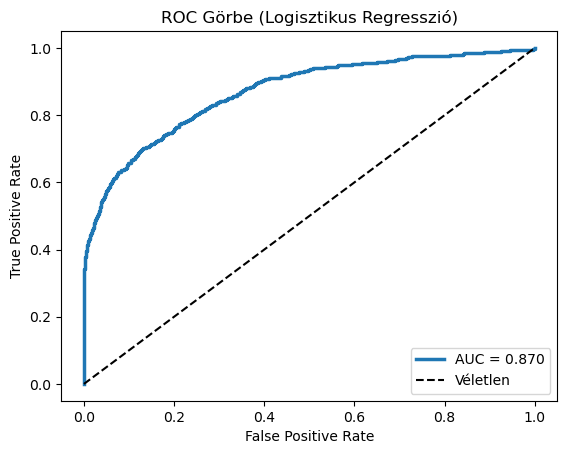

In [27]:
# ROC Görbe rajzolása és mentése

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', linewidth = 2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Véletlen')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Görbe (Logisztikus Regresszió)')
plt.legend(loc='lower right')
plt.savefig(f"roc_curve_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

<Figure size 800x600 with 0 Axes>

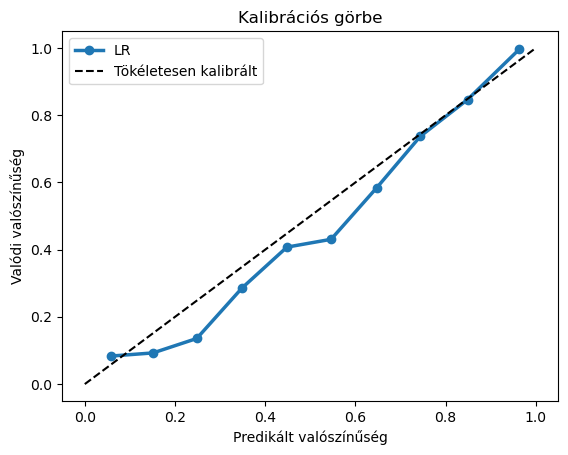

In [28]:
#Kalibrációs görbe

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label='LR', linewidth = 2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Tökéletesen kalibrált')

plt.xlabel('Predikált valószínűség')
plt.ylabel('Valódi valószínűség')
plt.title('Kalibrációs görbe')
plt.legend()

plt.savefig(f"calibration_curve_{DATASET_NAME}.png", bbox_inches='tight' , dpi=300)
plt.show()

In [19]:
#egységes 3 modellre:

# Cseréld ki a modell nevét és a predikciókat mindenhol
plt.figure(figsize=(8, 6))
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Modell neve') # Ide jöhet: LR / XGB / MLP
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Tökéletesen kalibrált')

plt.xlabel('Predikált valószínűség')
plt.ylabel('Valódi valószínűség')
plt.title('Kalibrációs Görbe (LR)')
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3) # Opcionális, de segít az olvashatóságban

# Figyelj az egyedi fájlnévre!
plt.savefig(f"calibration_curve_egyeges_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.close()

In [20]:
# Feature importance - csak az értékek
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefs = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df_sorted = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns=['abs_coefficient'])

print(coef_df_sorted.head(15))

coef_df_sorted.to_csv(f"LR_feature_importances_{DATASET_NAME}.csv", index=False)

                                             feature  coefficient
141                        num_scaler__DeltaS2Time_2    -1.173400
143                        num_scaler__DeltaS3Time_2    -0.808694
133                            num_scaler__TrackTemp    -0.704586
14                              tfidf__final section     0.665790
5                           tfidf__corners technical    -0.596584
160                        num_scaler__DeltaTyreLife    -0.574948
129                              num_scaler__AirTemp     0.525672
16                                    tfidf__flowing    -0.520620
110                team_ohe__Team_Overtaker_Mercedes     0.505363
112           team_ohe__Team_Overtaker_RedBullRacing     0.495607
161               num_scaler__DRS_OTSector_Overtaker     0.451192
106                 team_ohe__Team_Overtaker_Ferrari     0.402148
140                        num_scaler__DeltaS2Time_1    -0.375757
81   driver_ohe__Driver_Overtaker_infrequent_sklearn    -0.371288
151       

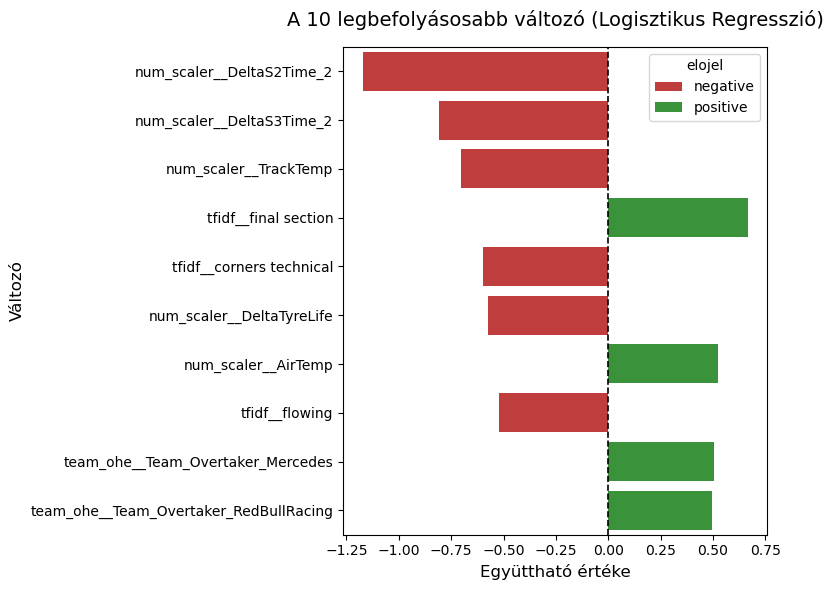

In [29]:
# Feature importance ábrázolása

coef_df['elojel'] = np.where(coef_df['coefficient'] >= 0, 'positive', 'negative')

#segédoszlop létrehozása az abszolút értékekkel
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df_sorted = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns=['abs_coefficient'])

top_10_features = coef_df_sorted.head(10)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_10_features, 
    x='coefficient', 
    y='feature', 
    hue='elojel', 
    dodge=False, 
    palette={'positive': '#2ca02c', 'negative': '#d62728'} # Zöld és piros színek
)

plt.title('A 10 legbefolyásosabb változó (Logisztikus Regresszió)', fontsize=14, pad=15)
plt.xlabel('Együttható értéke', fontsize=12)
plt.ylabel('Változó', fontsize=12)

#origón átmenő függőleges vonal
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')

plt.tight_layout()

plt.savefig(f"LR_feature_importances_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)

plt.show()

In [30]:
# A legjobb modell indexének megkeresése a RS eredményei között
best_index = random_search.best_index_

# A nyertes modell CV F1 átlaga és szórása (mivel a random_searchSearch-ben scoring='f1' volt)
cv_mean = random_search.best_score_
cv_std = random_search.cv_results_['std_test_score'][best_index]

# Béták (paraméterek) számának kinyerése a best_model-ből!
num_params = model.named_steps['classifier'].coef_.shape[1] + 1

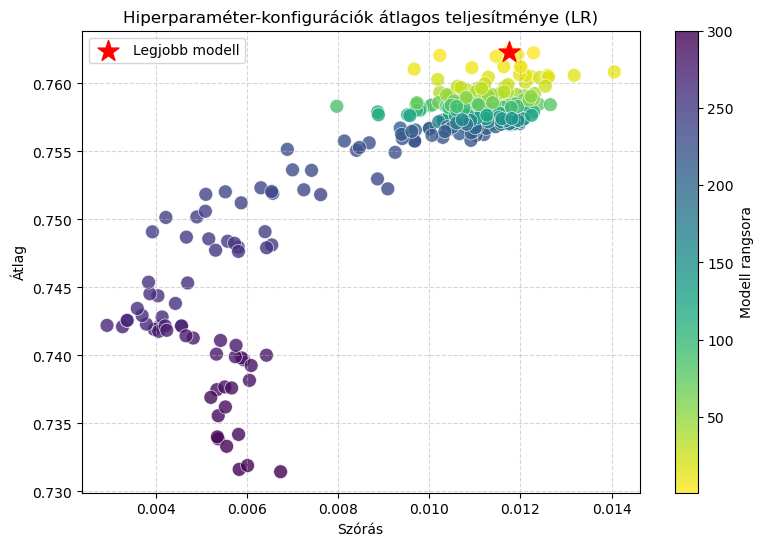

In [31]:
#CV mutatók alakulása a tanítás során + ábrázolás
cv_results = pd.DataFrame(random_search.cv_results_)

cv_results[['mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head()


plt.figure(figsize=(9, 6))

# Szóródiagram, ahol a szín a rangsort jelöli (minél kisebb a rank, annál sötétebb/másabb a szín)
scatter = plt.scatter(
    cv_results['std_test_score'],
    cv_results['mean_test_score'],
    c=cv_results['rank_test_score'],
    cmap='viridis_r', # Fordított viridis, hogy az 1-es helyezettek élénkek legyenek
    alpha=0.8,
    edgecolors='w', # Fehér keret a pontoknak a jobb elkülönülésért
    linewidth=0.5,
    s=100
)

# A legjobb modell megkeresése és kiemelése
best_cv_model = cv_results[cv_results['rank_test_score'] == 1].iloc[0]
plt.scatter(
    best_cv_model['std_test_score'], 
    best_cv_model['mean_test_score'],
    color='red', 
    marker='*', 
    s=250, # Nagy méret
    label='Legjobb modell',
    zorder=5 #hogy biztosan a többi pont felett jelenjen meg
)

# Színskála (Colorbar) hozzáadása
cbar = plt.colorbar(scatter)
cbar.set_label('Modell rangsora')

# Tengelyek és címek
plt.xlabel('Szórás')
plt.ylabel('Átlag')
plt.title('Hiperparaméter-konfigurációk átlagos teljesítménye (LR)')

# Rács és jelmagyarázat
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Mentés és megjelenítés
plt.savefig(f'CV_alakulas_{DATASET_NAME}_javitott.png', bbox_inches='tight', dpi=300)
plt.show()

#A pontok egy emelkedő trendet mutatnak: ahogy nő a modell jósága (Y-tengely), úgy nő vele együtt a bizonytalansága is (X-tengely).
#Ez a gépi tanulás klasszikus dilemmája: a komplexebb vagy kevésbé korlátozott modellek jobban teljesítenek, de sérülékenyebbek

In [ ]:
#n_iter = pontok száma !
print(f"Az ábrán összesen {len(cv_results)} pont (modell-konfiguráció) látható.")

In [32]:
#Eredmények mentése
metrics_dict = {
    "Model": "Logistic Regression Pipeline (RandomSearch)",
    "Number_of_Parameters": int(num_params),
    "CV_Mean_F1": float(cv_mean),         
    "CV_F1_Std": float(cv_std),           
    "Test_Accuracy": float(accuracy),
    "Test_F1_Score": float(f1),
    "Best_Threshold": float(best_t),     
    "AUC_ROC": float(auc),
    "Binary_CrossEntropy": float(bce),
    "Brier_Calibration_Score": float(brier)
}

print("\n--- Teljesítménymutatók ---")
for key, value in metrics_dict.items():
    # Ha az érték lebegőpontos szám (float), akkor 4 tizedesjegyre kerekítve írjuk ki
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    # Minden más esetben (szöveg vagy egész szám) simán kiírjuk
    else:
        print(f"{key}: {value}")

# JSON fájlba mentés
with open(f'logistic_regression_metrics_{DATASET_NAME}.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)


--- Teljesítménymutatók ---
Model: Logistic Regression Pipeline (RandomSearch)
Number_of_Parameters: 168
CV_Mean_F1: 0.7623
CV_F1_Std: 0.0117
Test_Accuracy: 0.7804
Test_F1_Score: 0.7500
Best_Threshold: 0.4960
AUC_ROC: 0.8697
Binary_CrossEntropy: 0.4576
Brier_Calibration_Score: 0.1448


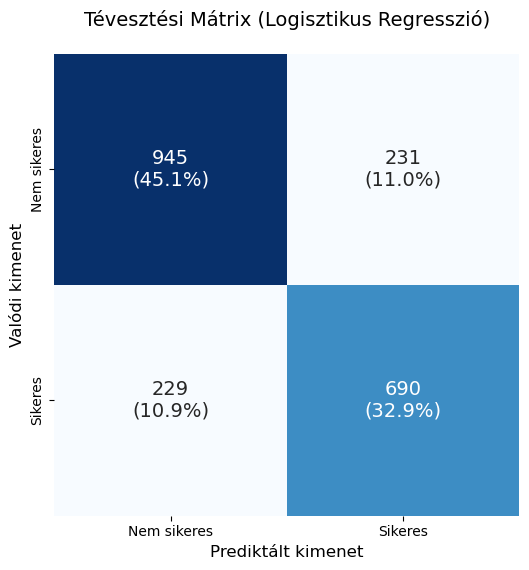

In [33]:
# Tévesztési mátrix kiszámítása
# Ha a predikciókat máshogy hívod, cseréld ki a 'test_preds_binary'-t (pl. 'y_pred'-re)
cm_lr = confusion_matrix(y_test, y_pred)

# Százalékok kiszámítása
cm_percentages_lr = cm_lr / np.sum(cm_lr)

# Feliratok létrehozása (darabszám és százalék)
labels_lr = [f"{count}\n({percent:.1%})" for count, percent in zip(cm_lr.flatten(), cm_percentages_lr.flatten())]
labels_lr = np.asarray(labels_lr).reshape(2, 2)

# Ábrázolás
plt.figure(figsize=(6, 6))
sns.heatmap(cm_lr, annot=labels_lr, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Nem sikeres', 'Sikeres'],
            yticklabels=['Nem sikeres', 'Sikeres'],
            annot_kws={"size": 14}) # A betűméretet itt tudod növelni

plt.xlabel('Prediktált kimenet', fontsize=12)
plt.ylabel('Valódi kimenet', fontsize=12)
plt.title("Tévesztési Mátrix (Logisztikus Regresszió)", fontsize=14, pad=20)

# Mentés és megjelenítés
plt.savefig(f"confusion_matrix_szazalekos_LR_{DATASET_NAME}.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Ha rossz lenne a modell ezt valahol lehetne használni:

#calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
#calibrated_model.fit(X_train, y_train)